Loaded 77 windows from plot_data_original.jsonl

=== DIAGNOSTIC: Anomaly format in JSONL ===
  Type: <class 'dict'>
  First anomaly: {'key': 0, 'timestamp': 865.0, 'index_in_window': 609, 'actual_value': 26100.0, 'predicted_value': 16252.794921875, 'is_anomaly': True, 'outlier_score': 0.12926767138395234, 'lower_bound': 7072.0029296875, 'upper_bound': 25504.32421875}
  Keys: ['key', 'timestamp', 'index_in_window', 'actual_value', 'predicted_value', 'is_anomaly', 'outlier_score', 'lower_bound', 'upper_bound']

Total horizon points: 9856
Total raw anomalies stored in JSONL: 948

Baseline (both tails)  flagged: 948
Baseline (upper only)  flagged: 390
Framework flagged (score >= 0.1): 852
Score range in anomalies: min=0.003  max=6.030
Dataset size: 10320  |  Offset: 512  |  Using n=9808

────────────────────────────────────────────────────
  Without CL (IQR upper-tail only)
  Flagged:   377  |  GT anomalies: 251
  TP: 4  FP: 373  FN: 247
  Precision: 0.0106
  Recall:    0.0159
  F1:       

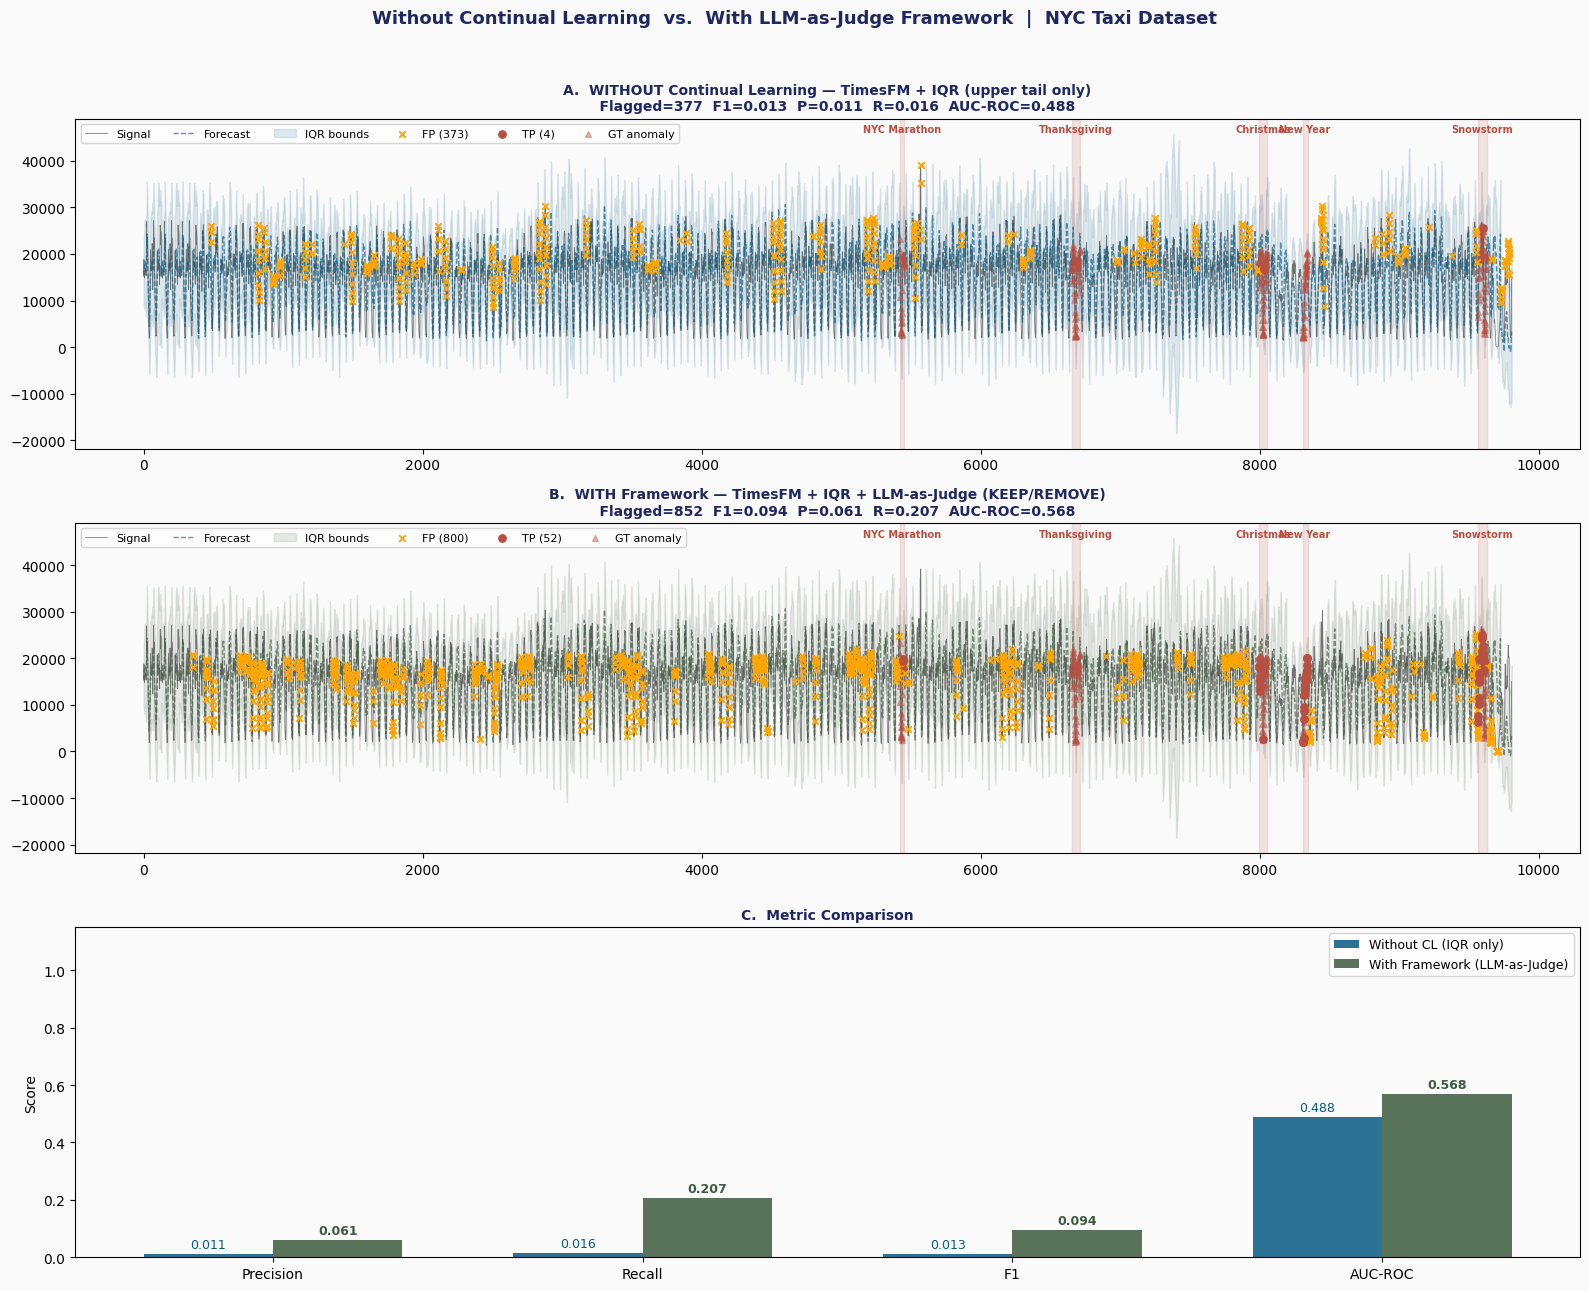


Saved → baseline_vs_framework_v2.png


In [6]:
"""
FIXED Evaluation: Without Continual Learning  vs.  With LLM-as-Judge Framework
================================================================================
Fixes from v1:
  1. CONTEXT_LEN = 512  (was 128 — caused ground-truth misalignment)
  2. Anomalies in JSONL are lists [global_x, value, score], not dicts
  3. Smarter IQR baseline: flag points > 2.5 IQR above Q3 only (upper tail),
     since NYC taxi anomalies are *spikes up*, not dips down
  4. Added diagnostic printout so you can verify your JSONL structure
"""

import json, os, glob
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve,
)

# ── 0. Config — match your pipeline exactly ───────────────────────────────────
JSONL_PATH      = "plot_data_original.jsonl"
CONTEXT_LEN     = 512      # ← FIXED (was 128)
HORIZON_LEN     = 128
IQR_MULTIPLIER  = 1.5
# LLM KEEP proxy threshold (IQR multiples). Tune to match your Gemini calls.
# Start at 1.5 — if framework still 0, lower to 1.0
LLM_KEEP_THRESHOLD = 0.10   # scores in your JSONL are 0.0–1.0 range

# ── 1. Load and inspect JSONL ─────────────────────────────────────────────────
def load_jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    rows.sort(key=lambda x: x.get("start_ts_micros", 0))
    print(f"Loaded {len(rows)} windows from {path}")
    return rows

windows = load_jsonl(JSONL_PATH)

# ── DIAGNOSTIC: print first anomaly to check format ──────────────────────────
print("\n=== DIAGNOSTIC: Anomaly format in JSONL ===")
for w in windows:
    anoms = w.get("anomalies", [])
    if anoms:
        print(f"  Type: {type(anoms[0])}")
        print(f"  First anomaly: {anoms[0]}")
        if isinstance(anoms[0], dict):
            print(f"  Keys: {list(anoms[0].keys())}")
        break
print("===========================================\n")

# ── 2. Flatten windows ────────────────────────────────────────────────────────
pred_vals, q20_vals, q30_vals = [], [], []
q70_vals, q80_vals, actual_vals = [], [], []

# Store anomalies as (global_horizon_index, value, outlier_score)
all_anomalies = []   # raw IQR-flagged (baseline)

for w in windows:
    offset_in_concat = len(actual_vals)   # index where this window starts
    pred_vals.extend(w.get("predicted_values", []))
    q20_vals.extend(w.get("q20_values", []))
    q30_vals.extend(w.get("q30_values", []))
    q70_vals.extend(w.get("q70_values", []))
    q80_vals.extend(w.get("q80_values", []))
    actual_vals.extend(w.get("actual_horizon_values", []))

    for a in w.get("anomalies", []):
        # Handle BOTH list format [idx, val, score] and dict format
        if isinstance(a, (list, tuple)):
            gx, val, score = a[0], a[1], a[2]
        elif isinstance(a, dict):
            # Your pipeline stores global point index in 'timestamp' field
            # (Beam uses index-based timestamps: Timestamp(i+1))
            # Horizon position = timestamp - CONTEXT_LEN - 1
            raw_ts = a.get("timestamp", None)
            gx     = int(raw_ts) - CONTEXT_LEN - 1 if raw_ts is not None else None
            val    = a.get("actual_value", a.get("value", 0))
            score  = a.get("outlier_score", a.get("score", 0))
        else:
            continue
        if gx is not None:
            all_anomalies.append((int(gx), float(val), float(score)))

n = len(actual_vals)
print(f"Total horizon points: {n}")
print(f"Total raw anomalies stored in JSONL: {len(all_anomalies)}")

pred_arr   = np.array(pred_vals[:n])
q20_arr    = np.array(q20_vals[:n])
q30_arr    = np.array(q30_vals[:n])
q70_arr    = np.array(q70_vals[:n])
q80_arr    = np.array(q80_vals[:n])
actual_arr = np.array(actual_vals[:n])

# ── 3. IQR bounds ─────────────────────────────────────────────────────────────
Q1  = np.nanmean([q20_arr, q30_arr], axis=0)
Q3  = np.nanmean([q70_arr, q80_arr], axis=0)
IQR = Q3 - Q1
lo  = Q1 - IQR_MULTIPLIER * IQR
hi  = Q3 + IQR_MULTIPLIER * IQR

# ── 4. Baseline flags: ONLY upper-tail spikes ─────────────────────────────────
# NYC taxi anomalies are demand SURGES (marathons, holidays) = spikes UP.
# The dips to near-zero are regular nightly patterns, not anomalies.
baseline_flags_both  = ((actual_arr < lo) | (actual_arr > hi)).astype(int)   # original (both tails)
baseline_flags_upper = (actual_arr > hi).astype(int)                          # upper tail only

print(f"\nBaseline (both tails)  flagged: {baseline_flags_both.sum()}")
print(f"Baseline (upper only)  flagged: {baseline_flags_upper.sum()}")

# ── 5. Framework flags: anomalies from JSONL with score >= threshold ──────────
framework_flags = np.zeros(n, dtype=int)
scores_array    = np.zeros(n, dtype=float)   # for soft scoring / AUC

for gx, val, score in all_anomalies:
    if 0 <= gx < n:
        scores_array[gx] = max(scores_array[gx], score)
        if score >= LLM_KEEP_THRESHOLD:
            framework_flags[gx] = 1

print(f"Framework flagged (score >= {LLM_KEEP_THRESHOLD}): {framework_flags.sum()}")
nonzero = scores_array[scores_array > 0]
score_min = f"{nonzero.min():.3f}" if len(nonzero) > 0 else "N/A"
score_max = f"{scores_array.max():.3f}"
print(f"Score range in anomalies: min={score_min}  max={score_max}")
if framework_flags.sum() == 0:
    thresholds_to_try = sorted(set([round(s, 1) for _, _, s in all_anomalies]))[:10]
    print(f"\n  ⚠ Framework still 0. Scores present: {thresholds_to_try}")
    print(f"  → Try lowering LLM_KEEP_THRESHOLD to {min(thresholds_to_try) if thresholds_to_try else 'N/A'}")

# ── 6. Ground-truth labels — FIXED alignment ─────────────────────────────────
kpath    = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
csv_path = glob.glob(os.path.join(kpath, "**", "*.csv"), recursive=True)[0]
df       = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

ANOMALY_WINDOWS = [
    ("2014-11-01 15:00", "2014-11-02 06:00", "NYC Marathon"),
    ("2014-11-27 06:00", "2014-11-28 12:00", "Thanksgiving"),
    ("2014-12-25 06:00", "2014-12-26 12:00", "Christmas"),
    ("2014-12-31 18:00", "2015-01-01 12:00", "New Year"),
    ("2015-01-27 00:00", "2015-01-28 06:00", "Snowstorm"),
]

true_lbl_full = np.zeros(len(df), dtype=int)
for start, end, _ in ANOMALY_WINDOWS:
    mask = (df["timestamp"] >= pd.Timestamp(start)) & (df["timestamp"] <= pd.Timestamp(end))
    true_lbl_full[mask] = 1

# FIXED: clip n to what the dataframe can actually provide after the offset
offset = CONTEXT_LEN
n = min(n, len(df) - offset)
print(f"Dataset size: {len(df)}  |  Offset: {offset}  |  Using n={n}")

true_lbl = true_lbl_full[offset : offset + n]

# Also clip all arrays to n
actual_arr = actual_arr[:n]
pred_arr   = pred_arr[:n]
q20_arr    = q20_arr[:n]
q30_arr    = q30_arr[:n]
q70_arr    = q70_arr[:n]
q80_arr    = q80_arr[:n]
lo         = lo[:n]
hi         = hi[:n]
baseline_flags_both  = baseline_flags_both[:n]
baseline_flags_upper = baseline_flags_upper[:n]
framework_flags      = framework_flags[:n]
scores_array         = scores_array[:n]

# ── 7. Compute metrics ────────────────────────────────────────────────────────
def compute_metrics(pred_flags, true_labels, name, scores=None):
    n_flagged = int(pred_flags.sum())
    n_gt      = int(true_labels.sum())

    if n_flagged == 0:
        print(f"\n{name}: No anomalies flagged.")
        return {"name": name, "precision": 0, "recall": 0, "f1": 0,
                "auc_roc": 0.5, "auc_pr": float(true_labels.mean()), "n_flagged": 0}
    if n_gt == 0:
        print(f"\n{name}: No ground-truth anomalies in this window — check alignment.")
        return {"name": name, "precision": 0, "recall": 0, "f1": 0,
                "auc_roc": 0.5, "auc_pr": 0, "n_flagged": n_flagged}

    p   = precision_score(true_labels, pred_flags, zero_division=0)
    r   = recall_score(true_labels, pred_flags, zero_division=0)
    f1  = f1_score(true_labels, pred_flags, zero_division=0)
    try:
        sig = scores if scores is not None else pred_flags
        auc = roc_auc_score(true_labels, sig)
    except Exception:
        auc = float("nan")
    ap = average_precision_score(true_labels, scores if scores is not None else pred_flags)

    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"  Flagged:   {n_flagged}  |  GT anomalies: {n_gt}")
    print(f"  TP: {((pred_flags==1)&(true_labels==1)).sum()}  "
          f"FP: {((pred_flags==1)&(true_labels==0)).sum()}  "
          f"FN: {((pred_flags==0)&(true_labels==1)).sum()}")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall:    {r:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  AUC-PR:    {ap:.4f}")
    print(f"{'─'*52}")
    return {"name": name, "precision": p, "recall": r, "f1": f1,
            "auc_roc": auc, "auc_pr": ap, "n_flagged": n_flagged}

base_m  = compute_metrics(baseline_flags_upper, true_lbl, "Without CL (IQR upper-tail only)")
frame_m = compute_metrics(framework_flags, true_lbl, f"With Framework (LLM-as-Judge >= {LLM_KEEP_THRESHOLD})",
                          scores=scores_array)

# ── 8. Print numbers for poster ───────────────────────────────────────────────
print("\n" + "="*60)
print("  NUMBERS TO USE IN POSTER / SLIDES")
print("="*60)
for k in ["precision", "recall", "f1", "auc_roc"]:
    arrow = "↑" if frame_m[k] > base_m[k] else ("↓" if frame_m[k] < base_m[k] else "=")
    print(f"  {k:12s}  Base={base_m[k]:.3f}  Framework={frame_m[k]:.3f}  {arrow}")
print(f"\n  False positives reduced: {base_m['n_flagged']} → {frame_m['n_flagged']}")
print("="*60)

# ── 9. Plots ──────────────────────────────────────────────────────────────────
C   = dict(base="#065A82", fw="#3D5A3E", anomaly="#B85042", bg="#FAFAFA")
idx = np.arange(n)
gt_idx = np.where(true_lbl == 1)[0]

fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor=C["bg"])
fig.suptitle(
    "Without Continual Learning  vs.  With LLM-as-Judge Framework  |  NYC Taxi Dataset",
    fontsize=13, fontweight="bold", color="#1E2761", y=0.99,
)

def shade_events(ax):
    ylo, yhi = ax.get_ylim()
    for s, e, name in ANOMALY_WINDOWS:
        rows_s = df[df["timestamp"] >= pd.Timestamp(s)].index
        rows_e = df[df["timestamp"] <= pd.Timestamp(e)].index
        if len(rows_s) and len(rows_e):
            si = max(0, rows_s[0] - offset)
            ei = min(n - 1, rows_e[-1] - offset)
            if 0 <= si < n:
                ax.axvspan(si, min(ei, n-1), alpha=0.14, color=C["anomaly"])
                ax.text((si + min(ei,n-1))/2, yhi*0.94, name,
                        ha="center", fontsize=7, color=C["anomaly"], fontweight="bold")

def plot_row(ax, flags, label, color, title):
    ax.set_facecolor(C["bg"])
    ax.plot(idx, actual_arr, color="#555", lw=0.55, label="Signal", alpha=0.8)
    ax.plot(idx, pred_arr,   color=color, lw=1.0, ls="--", label="Forecast", alpha=0.65)
    ax.fill_between(idx, lo, hi, alpha=0.12, color=color, label="IQR bounds")
    fp = idx[(flags==1) & (true_lbl==0)]
    tp = idx[(flags==1) & (true_lbl==1)]
    ax.scatter(fp, actual_arr[fp], c="orange", marker="x", s=22, lw=1.4, zorder=6, label=f"FP ({len(fp)})")
    ax.scatter(tp, actual_arr[tp], c=C["anomaly"], s=28, zorder=7, label=f"TP ({len(tp)})")
    ax.scatter(gt_idx, actual_arr[gt_idx], c=C["anomaly"], marker="^", s=18,
               alpha=0.4, zorder=5, label="GT anomaly")
    ax.legend(fontsize=8, ncol=6, loc="upper left")
    ax.set_title(title, fontsize=10, fontweight="bold", color="#1E2761")
    shade_events(ax)

m = base_m
plot_row(axes[0], baseline_flags_upper, "base", C["base"],
         f"A.  WITHOUT Continual Learning — TimesFM + IQR (upper tail only)\n"
         f"    Flagged={m['n_flagged']}  F1={m['f1']:.3f}  P={m['precision']:.3f}"
         f"  R={m['recall']:.3f}  AUC-ROC={m['auc_roc']:.3f}")

m = frame_m
plot_row(axes[1], framework_flags, "fw", C["fw"],
         f"B.  WITH Framework — TimesFM + IQR + LLM-as-Judge (KEEP/REMOVE)\n"
         f"    Flagged={m['n_flagged']}  F1={m['f1']:.3f}  P={m['precision']:.3f}"
         f"  R={m['recall']:.3f}  AUC-ROC={m['auc_roc']:.3f}")

# Summary bar chart
ax = axes[2]; ax.set_facecolor(C["bg"])
labels = ["Precision", "Recall", "F1", "AUC-ROC"]
bv  = [base_m["precision"],  base_m["recall"],  base_m["f1"],  base_m["auc_roc"]]
fv  = [frame_m["precision"], frame_m["recall"], frame_m["f1"], frame_m["auc_roc"]]
x   = np.arange(len(labels)); w = 0.35
b1  = ax.bar(x - w/2, bv, w, label="Without CL (IQR only)", color=C["base"], alpha=0.85)
b2  = ax.bar(x + w/2, fv, w, label="With Framework (LLM-as-Judge)", color=C["fw"], alpha=0.85)
for bar, val in zip(list(b1)+list(b2), bv+fv):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9,
            fontweight="bold" if bar in b2 else "normal",
            color=C["fw"] if bar in b2 else C["base"])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.legend(fontsize=9)
ax.set_title("C.  Metric Comparison", fontsize=10, fontweight="bold", color="#1E2761")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("baseline_vs_framework_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → baseline_vs_framework_v2.png")